In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 


In [45]:
df = pd.read_csv("https://gist.githubusercontent.com/rogernogueira/d0d6f8068d5970c79b1d36c3bc0b27af/raw/c9f08ee77a2f37c70e99d2a683940429da2be29f/vendas_cursos_ia.csv")

In [46]:
df.head(15)

,id_cliente,idade,sexo,data_adesao,plano,status,valor_mensal,suporte_tickets,feedback_score,meses_ativo,total_gasto
0,1,NaN,F,2022-11-05,Basico,Ativo,49.9,2,6.0,18,898.2
1,2,46.0,M,2022-08-15,Gratuito,Ativo,0.0,3,8.0,9,0.0
2,3,32.0,F,2022-12-18,Premium,Ativo,99.9,1,9.0,2,199.8
3,4,60.0,M,2023-05-21,Premium,Ativo,99.9,3,6.0,2,199.8
4,5,25.0,Nao_Informado,2022-10-22,Basico,Cancelado,49.9,3,1.0,3,149.7
5,6,38.0,M,2023-10-25,Gratuito,Cancelado,0.0,5,3.0,16,0.0
6,7,56.0,M,2022-04-30,Premium,Ativo,99.9,3,6.0,19,1898.1
7,8,36.0,M,2022-01-11,Basico,Ativo,49.9,2,8.0,4,199.6
8,9,40.0,Nao_Informado,2022-06-15,Premium,Ativo,99.9,2,10.0,23,2297.7
9,10,28.0,F,2023-07-04,Premium,Cancelado,99.9,10,1.0,18,1798.2


In [47]:
df.info

<bound method DataFrame.info of       id_cliente  idade           sexo data_adesao     plano     status  \
0              1    NaN              F  2022-11-05    Basico      Ativo   
1              2   46.0              M  2022-08-15  Gratuito      Ativo   
2              3   32.0              F  2022-12-18   Premium      Ativo   
3              4   60.0              M  2023-05-21   Premium      Ativo   
4              5   25.0  Nao_Informado  2022-10-22    Basico  Cancelado   
...          ...    ...            ...         ...       ...        ...   
1195        1196   23.0              F  2023-10-28    Basico      Ativo   
1196        1197   41.0              M  2023-11-29    Basico      Ativo   
1197        1198   50.0              M  2023-11-17    Basico      Ativo   
1198        1199   46.0              M  2023-09-04  Gratuito  Cancelado   
1199        1200   60.0              M  2023-02-24   Premium  Cancelado   

     valor_mensal  suporte_tickets  feedback_score  meses_ativo  to

In [48]:
df.columns

Index(['id_cliente', 'idade', 'sexo', 'data_adesao', 'plano', 'status',
       'valor_mensal', 'suporte_tickets', 'feedback_score', 'meses_ativo',
       'total_gasto'],
      dtype='str')

In [49]:
print(df.head())
print(df.info())
print(df.describe())

   id_cliente  idade           sexo data_adesao     plano     status  \
0           1    NaN              F  2022-11-05    Basico      Ativo   
1           2   46.0              M  2022-08-15  Gratuito      Ativo   
2           3   32.0              F  2022-12-18   Premium      Ativo   
3           4   60.0              M  2023-05-21   Premium      Ativo   
4           5   25.0  Nao_Informado  2022-10-22    Basico  Cancelado   

  valor_mensal  suporte_tickets  feedback_score  meses_ativo  total_gasto  
0         49.9                2             6.0           18        898.2  
1          0.0                3             8.0            9          0.0  
2         99.9                1             9.0            2        199.8  
3         99.9                3             6.0            2        199.8  
4         49.9                3             1.0            3        149.7  
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column    

In [50]:
df.columns = df.columns.str.strip().str.lower()

In [51]:
mapa_valores = {
    'quarenta_e_nove': 49
}

df['valor_mensal'] = df['valor_mensal'].replace(mapa_valores)
df['valor_mensal'] = pd.to_numeric(df['valor_mensal'], errors='coerce')

In [52]:
df['idade'] = pd.to_numeric(df['idade'], errors='coerce')

df['idade'] = df['idade'].apply(
    lambda x: 'idade_invalida' if (pd.isna(x) or x < 10 or x > 100) else int(x)
)

In [53]:
df.isnull().sum()

id_cliente          0
idade               0
sexo                0
data_adesao         0
plano               0
status              0
valor_mensal        0
suporte_tickets     0
feedback_score     30
meses_ativo         0
total_gasto        20
dtype: int64

In [54]:
df['feedback_score'] = df['feedback_score'].fillna(0)

In [55]:
df['deu_feedback'] = df['feedback_score'] > 0

In [56]:
df['risco_cancelamento'] = (
    (df['feedback_score'] <= 5) |
    (df['suporte_tickets'] >= 5)
)

In [57]:
df.isnull().sum()

id_cliente             0
idade                  0
sexo                   0
data_adesao            0
plano                  0
status                 0
valor_mensal           0
suporte_tickets        0
feedback_score         0
meses_ativo            0
total_gasto           20
deu_feedback           0
risco_cancelamento     0
dtype: int64

In [58]:
resumo = pd.pivot_table(
    df,
    values='total_gasto',
    index='status',
    aggfunc=['sum', 'mean', 'count']
)

resumo.columns = ['faturamento_total', 'gasto_medio_por_cliente', 'quantidade_clientes']

resumo['faturamento_total'] = resumo['faturamento_total'].apply(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
resumo['gasto_medio_por_cliente'] = resumo['gasto_medio_por_cliente'].apply(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))

print(resumo)

          faturamento_total gasto_medio_por_cliente  quantidade_clientes
status                                                                  
Ativo         R$ 540.272,90               R$ 689,12                  784
Cancelado     R$ 261.812,60               R$ 661,14                  396


In [59]:
df['cancelou'] = df['status'].apply(lambda x: 1 if x.lower() == 'cancelado' else 0)

In [60]:

print("\n TAXA GERAL DE CANCELAMENTO:")
print(df['cancelou'].value_counts(normalize=True) * 100)

print("\n CANCELAMENTO POR PLANO:")
print(df.groupby('plano')['cancelou'].mean().sort_values(ascending=False))

print("\n CANCELAMENTO POR FEEDBACK:")
print(df.groupby('feedback_score')['cancelou'].mean())

print("\n CANCELAMENTO POR SUPORTE:")
print(df.groupby('suporte_tickets')['cancelou'].mean().sort_values(ascending=False))

print("\n CANCELAMENTO POR RISCO:")
print(df.groupby('risco_cancelamento')['cancelou'].mean())


 TAXA GERAL DE CANCELAMENTO:
cancelou
0    66.5
1    33.5
Name: proportion, dtype: float64

 CANCELAMENTO POR PLANO:
plano
Gratuito    0.375527
Basico      0.332220
Premium     0.313187
Name: cancelou, dtype: float64

 CANCELAMENTO POR FEEDBACK:
feedback_score
0.0     0.233333
1.0     1.000000
2.0     1.000000
3.0     1.000000
4.0     1.000000
5.0     1.000000
6.0     0.000000
7.0     0.000000
8.0     0.000000
9.0     0.000000
10.0    0.000000
Name: cancelou, dtype: float64

 CANCELAMENTO POR SUPORTE:
suporte_tickets
4     1.000000
5     1.000000
6     1.000000
7     1.000000
8     1.000000
9     1.000000
10    1.000000
11    1.000000
3     0.204545
0     0.000000
1     0.000000
2     0.000000
Name: cancelou, dtype: float64

 CANCELAMENTO POR RISCO:
risco_cancelamento
False    0.000000
True     0.945882
Name: cancelou, dtype: float64


In [61]:
(df['feedback_score'] <= 5) | (df['suporte_tickets'] >= 5)
df[df['risco_cancelamento'] == True].head()

,id_cliente,idade,sexo,data_adesao,plano,status,valor_mensal,suporte_tickets,feedback_score,meses_ativo,total_gasto,deu_feedback,risco_cancelamento,cancelou
4,5,25,Nao_Informado,2022-10-22,Basico,Cancelado,49.9,3,1.0,3,149.7,True,True,1
5,6,38,M,2023-10-25,Gratuito,Cancelado,0.0,5,3.0,16,0.0,True,True,1
9,10,28,F,2023-07-04,Premium,Cancelado,99.9,10,1.0,18,1798.2,True,True,1
17,18,19,M,2023-05-14,Basico,Cancelado,49.9,3,5.0,16,798.4,True,True,1
20,21,47,M,2023-11-21,Premium,Cancelado,99.9,4,5.0,2,199.8,True,True,1


In [62]:
df[(df['risco_cancelamento'] == True) & (df['cancelou'] == 0)]

,id_cliente,idade,sexo,data_adesao,plano,status,valor_mensal,suporte_tickets,feedback_score,meses_ativo,total_gasto,deu_feedback,risco_cancelamento,cancelou
66,67,46,F,2023-09-05,Basico,Ativo,49.9,2,0.0,12,598.8,False,True,0
118,119,50,M,2022-09-12,Basico,Ativo,49.9,2,0.0,15,748.5,False,True,0
126,127,44,M,2022-03-20,Gratuito,Ativo,0.0,3,0.0,16,0.0,False,True,0
139,140,44,F,2022-08-19,Premium,Ativo,99.9,2,0.0,16,1598.4,False,True,0
142,143,32,F,2023-04-19,Basico,Ativo,49.9,2,0.0,11,548.9,False,True,0
241,242,20,F,2022-05-24,Basico,Ativo,49.9,0,0.0,4,199.6,False,True,0
417,418,62,M,2023-10-10,Basico,Ativo,49.9,2,0.0,12,598.8,False,True,0
487,488,21,M,2022-01-14,Basico,Ativo,49.9,3,0.0,9,449.1,False,True,0
490,491,33,F,2022-01-02,Gratuito,Ativo,0.0,3,0.0,12,0.0,False,True,0
491,492,19,F,2022-04-09,Premium,Ativo,99.9,0,0.0,6,599.4,False,True,0


In [63]:
tabela_planos = df.groupby('plano')['total_gasto'].agg(
    faturamento_total='sum',
    gasto_medio='mean',
    quantidade_clientes='count'
).reset_index()

tabela_planos['faturamento_total'] = tabela_planos['faturamento_total'].apply(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

tabela_planos['gasto_medio'] = tabela_planos['gasto_medio'].apply(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

print(tabela_planos)

      plano faturamento_total  gasto_medio  quantidade_clientes
0    Basico     R$ 360.527,50    R$ 615,23                  586
1  Gratuito           R$ 0,00      R$ 0,00                  234
2   Premium     R$ 441.558,00  R$ 1.226,55                  360


In [64]:
tabela_planos = df.groupby('plano').agg(
    faturamento_total=('total_gasto', 'sum'),
    gasto_medio=('total_gasto', 'mean'),
    quantidade_clientes=('total_gasto', 'count'),
    taxa_churn=('cancelou', 'mean')
).reset_index()

In [65]:
tabela_planos

,plano,faturamento_total,gasto_medio,quantidade_clientes,taxa_churn
0,Basico,360527.5,615.234642,586,0.332220
1,Gratuito,0.0,0.000000,234,0.375527
2,Premium,441558.0,1226.550000,360,0.313187


In [66]:
plt.style.use('default')
sns.set_theme(style="whitegrid")

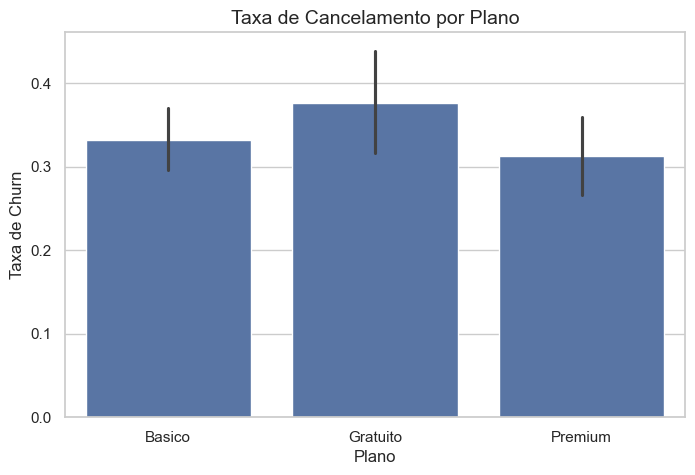

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='plano',
    y='cancelou'
)

plt.title('Taxa de Cancelamento por Plano', fontsize=14)
plt.xlabel('Plano')
plt.ylabel('Taxa de Churn')

plt.show()

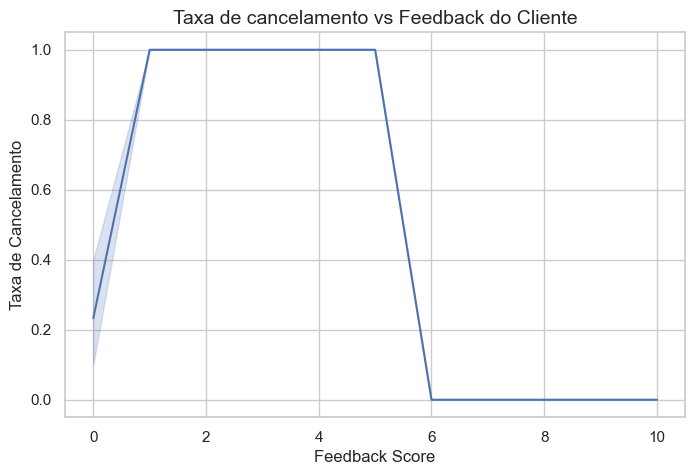

In [68]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df,
    x='feedback_score',
    y='cancelou'
)

plt.title('Taxa de cancelamento vs Feedback do Cliente', fontsize=14)
plt.xlabel('Feedback Score')
plt.ylabel('Taxa de Cancelamento')

plt.show()

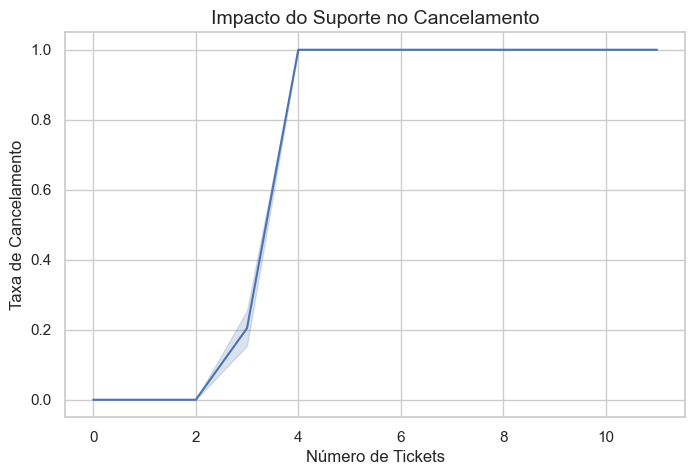

In [69]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df,
    x='suporte_tickets',
    y='cancelou'
)

plt.title('Impacto do Suporte no Cancelamento', fontsize=14)
plt.xlabel('Número de Tickets')
plt.ylabel('Taxa de Cancelamento')

plt.show()

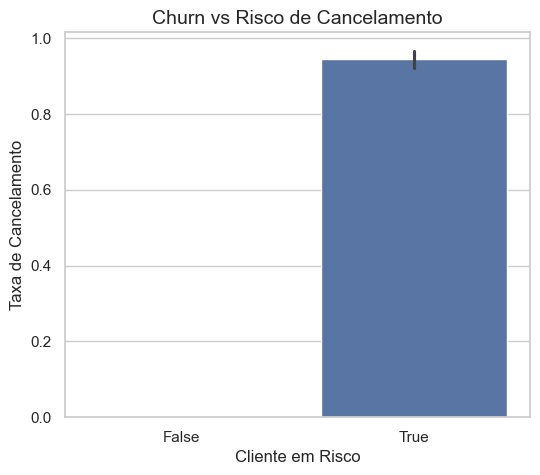

In [70]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x='risco_cancelamento',
    y='cancelou'
)

plt.title('Churn vs Risco de Cancelamento', fontsize=14)
plt.xlabel('Cliente em Risco')
plt.ylabel('Taxa de Cancelamento')

plt.show()

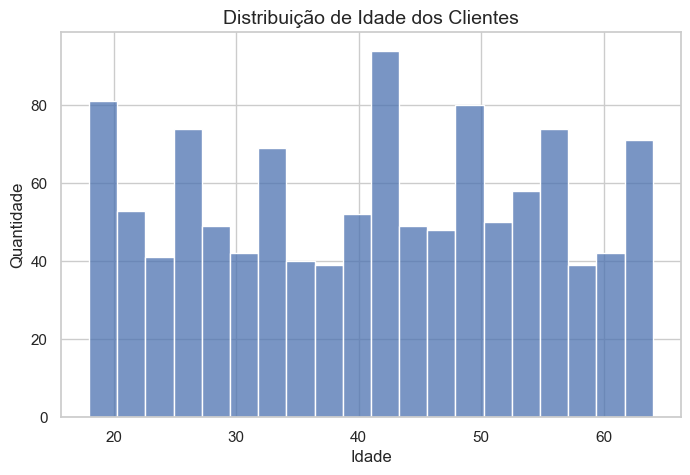

In [71]:
idade_temp = pd.to_numeric(df['idade'], errors='coerce')

plt.figure(figsize=(8,5))
sns.histplot(idade_temp.dropna(), bins=20)

plt.title('Distribuição de Idade dos Clientes', fontsize=14)
plt.xlabel('Idade')
plt.ylabel('Quantidade')

plt.show()

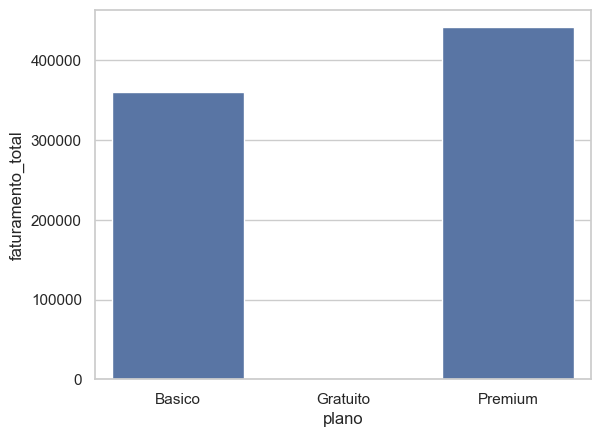

In [72]:
from matplotlib.ticker import FuncFormatter

def formato_real(x, pos):
    return f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

ax = sns.barplot(
    data=tabela_planos,
    x='plano',
    y='faturamento_total'
)

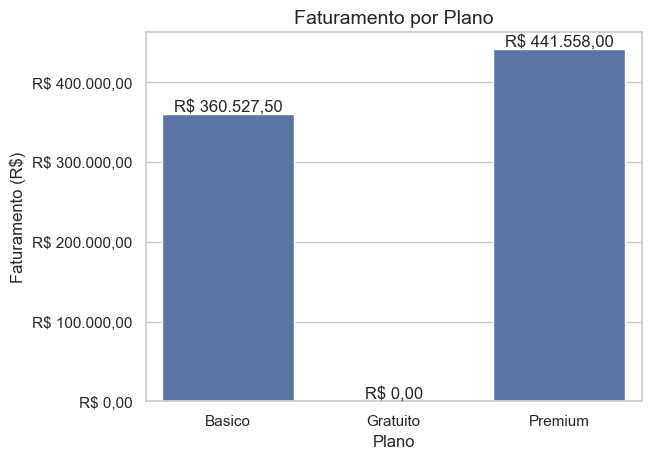

In [73]:
ax = sns.barplot(
    data=tabela_planos,
    x='plano',
    y='faturamento_total'
)

for p in ax.patches:
    valor = p.get_height()
    ax.annotate(formato_real(valor, 0),
                (p.get_x() + p.get_width() / 2., valor),
                ha='center', va='bottom')

plt.gca().yaxis.set_major_formatter(FuncFormatter(formato_real))

plt.title('Faturamento por Plano', fontsize=14)
plt.xlabel('Plano')
plt.ylabel('Faturamento (R$)')

plt.show()

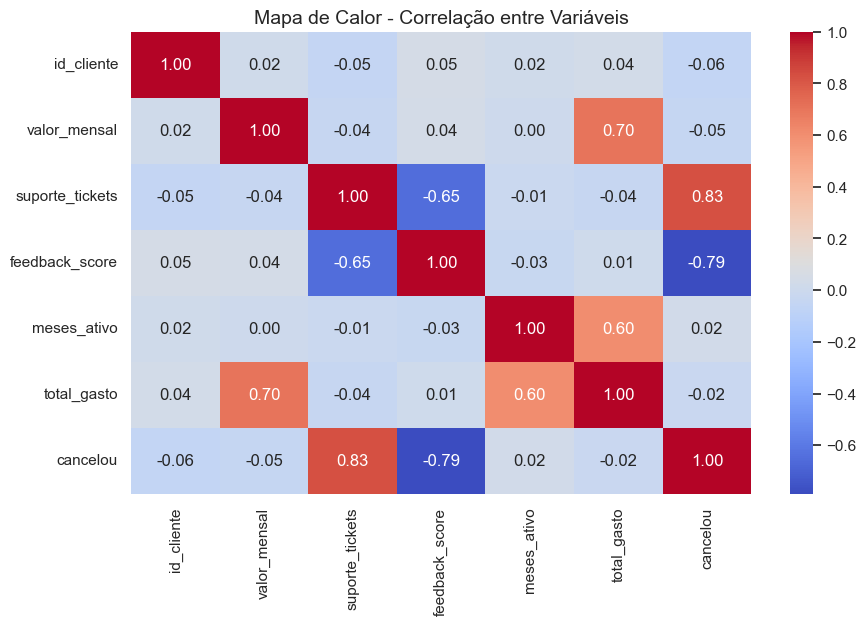

In [74]:
plt.figure(figsize=(10,6))

# Selecionar apenas colunas numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# Matriz de correlação
correlacao = df_numerico.corr()

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title('Mapa de Calor - Correlação entre Variáveis', fontsize=14)

plt.show()

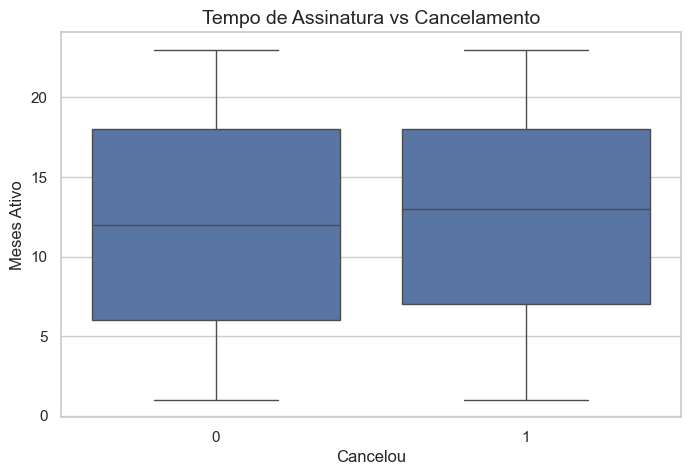

In [75]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='cancelou',
    y='meses_ativo'
)

plt.title('Tempo de Assinatura vs Cancelamento', fontsize=14)
plt.xlabel('Cancelou')
plt.ylabel('Meses Ativo')

plt.show()

<Axes: xlabel='plano', ylabel='cancelou'>

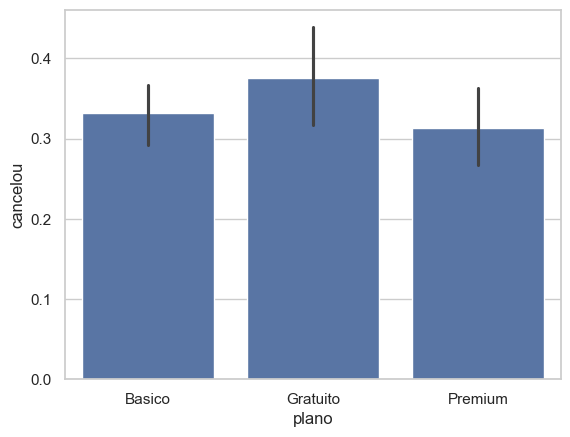

In [43]:
sns.barplot(data=df, x='plano', y='cancelou')